In [ ]:
%pip install -Uqq fastai ddgs

## Step 1. Gathering data

In [ ]:
"""Download images functions"""
from ddgs import DDGS
from fastdownload import download_url
import time
from pathlib import Path

def search_images(term, max_images=30, max_retries=3):
    """Tìm URL ảnh bằng DuckDuckGo, có retry khi lỗi."""
    for attempt in range(max_retries):
        try:
            with DDGS() as ddgs:
                results = ddgs.images(term, max_results=max_images)
                urls = [r["image"] for r in results]
            return urls
        except Exception as e:
            print(f"[search_images] Lỗi lần {attempt+1}/{max_retries} với '{term}': {e}")
            time.sleep(5)  # đợi trước khi thử lại
    print(f"[search_images] Bỏ qua '{term}' sau {max_retries} lần thử.")
    return []

def download_images(dest, urls, sleep_between=1.0):
    """Tải từng ảnh, bỏ qua ảnh lỗi, nghỉ giữa các lần tải."""
    dest = Path(dest)
    dest.mkdir(parents=True, exist_ok=True)
    for i, url in enumerate(urls):
        try:
            download_url(url, dest / f"{i:04d}.jpg", show_progress=False)
        except Exception as e:
            print(f"  bỏ qua ảnh {i} ({url[:60]}...): {e}")
        finally:
            time.sleep(sleep_between)  # nghỉ giữa mỗi lần tải, tránh bị chặn

In [ ]:
"Download images of different bear types"

bear_types = 'grizzly', 'black', 'teddy'
path = Path('bears')

for o in bear_types:
    dest = path/o
    dest.mkdir(exist_ok=True, parents=True)
    urls = search_images(f'{o} bear', max_images=100)
    download_images(dest, urls, sleep_between=0.5)
    time.sleep(3)  # nghỉ giữa các đợt search khác nhau

In [7]:
"Verify images and remove any that are corrupted"
from fastai.vision.all import verify_images, get_image_files
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)

[None]

## Step 2. Create Dataloaders

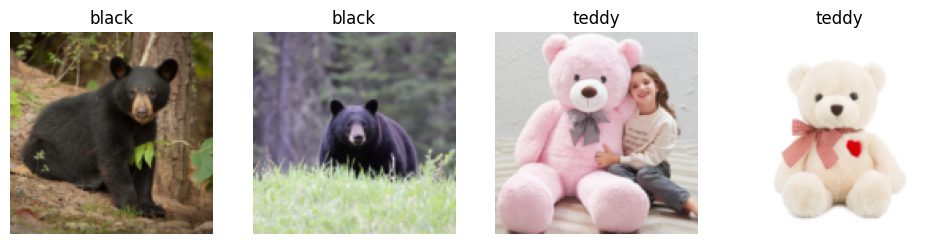

In [ ]:
from fastcore.all import *
from fastai.vision.all import *

bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128)
)


dls = bears.dataloaders(path)

dls.valid.show_batch(max_n=4, nrows=1)

## Step 3. Train a model to clean our data

In [ ]:

"Override the default transforms with our own"

bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())

In [15]:
"Train the model"

learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,2.046180,2.441653,0.473684,00:15


epoch,train_loss,valid_loss,error_rate,time
0,1.927110,1.484841,0.421053,00:15
1,1.501237,0.333960,0.157895,00:15
2,1.181944,0.050702,0.000000,00:14
3,0.912030,0.016984,0.000000,00:15


grizzly 30
black 33
teddy 35
train: 79 valid: 19


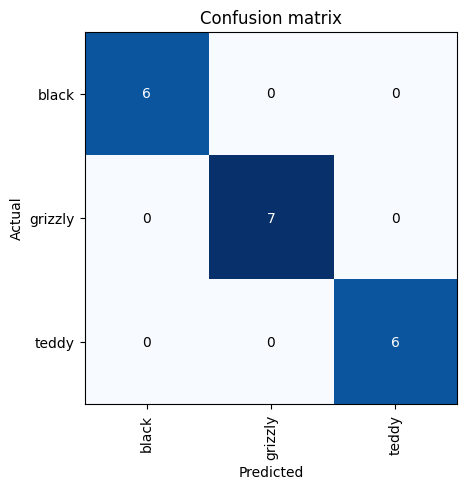

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

A confusion matrix is a table that shows you exactly what the model is confusing with what, instead of just giving you an overall accuracy number - and importantly, you have to judge for yourself which type of mistake is dangerous in the context of your real-world application, since the numbers themselves don't tell you that.

From the matrix, we can see that the model predict 100% correctly.

## Step 4. Cleaning the data with model predictions

The model itself can help find dirty data: `ImageClassifierCleaner` shows the images of each class ordered by increasing confidence (the ones the model is least sure about, or got wrong, come first), so we can review them and decide whether to delete or relabel.

In [ ]:
from fastai.vision.widgets import *

cleaner = ImageClassifierCleaner(learn)
cleaner

`ImageClassifierCleaner` doesn't actually delete or relabel anything for you — it just returns the indices of the items selected in the widget above (via the <Delete> menu, or by picking a different category). Run the two cells below to apply those choices:

In [ ]:
"Delete the images selected as <Delete>"
for idx in cleaner.delete():
    cleaner.fns[idx].unlink()

In [ ]:
"Move images that were relabeled to a different category into the right folder"
import shutil

for idx, cat in cleaner.change():
    shutil.move(str(cleaner.fns[idx]), path / cat)

**Note:** After deleting/relabeling, re-run `dls = bears.dataloaders(path)` and `learn.fine_tune(4)` to retrain on the cleaned data, and see if accuracy improves.

Since the model above already hit 100% accuracy on the validation set (no wrong cells in the confusion matrix), this dataset likely doesn't have much dirty data for the widget to flag — this cleaning step is most useful when the confusion matrix or loss shows real confusion between classes.

## Step 5. Export the model for deployment

`learn.export()` saves the model's architecture, trained weights, and the `DataLoaders` definition (so the exact same preprocessing/transforms are applied at inference time) into a single `.pkl` file. This is the only artifact we need to ship - no training code, no raw image folder.

In [29]:
learn.export('bear_classifier.pkl')
Path('bear_classifier.pkl').stat().st_size

46972145

In [31]:
"Fallback: copy to Google Drive, then download normally from drive.google.com"
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('bear_classifier.pkl', '/content/drive/MyDrive/bear_classifier.pkl')

Mounted at /content/drive


'/content/drive/MyDrive/bear_classifier.pkl'